<a href="https://colab.research.google.com/github/Saugat-Chaudhary/nn-zero-to-hero/blob/master/my_activities/micrograd/micrograd_p2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Micrograd Notebook part2 (Final build)
First we will import the same libraries that we did in first part.

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

_Note: This is the same `Value` class from our part 1 `Micrograd_p1.ipynb` but we will modify this function to work will all the mathematical operator and function as complete `micrograd`._

In [2]:
class Value:
  def __init__(self,data,_children=(),_op='',label=''):
    self.data = data
    self.grad = 0.0 # since every object will also have grad with initial value 0
    self._backward = lambda:None # this attribute stores a function to calculate backward propagation
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __radd__(self,other):
    return self + other

  def __add__(self,other):
    other = other if isinstance(other,Value)else Value(other)
    # if isinstance(other,Value): (object,class)
    #   other = other
    # else:
    #   other = Value(other)
    out = Value(self.data + other.data,(self,other),'+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward # we are storing the defined _backward function to calculate the grads
    return out

  def __rmul__(self,other): # other * self
    return self * other

  def __mul__(self,other):
    other = other if isinstance(other,Value) else Value(other)
    out = Value(self.data * other.data,(self,other),'*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
    return out

  def tanh(self):
    x = self.data
    t =(math.exp(2*x)-1)/(math.exp(2*x)+1)
    out = Value(t,(self,),'tanh') # why (self,) because we are saying python to make tuple containing only one element self or else it will ignorre because output, itself is being through activation function to form final output

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)

    build_topo(self)
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

  # part2 new operators implementation
  def exp(self):
    x=self.data
    out = Value(math.exp(x),(self,),'exp')

    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward
    return out

  def __neg__(self):# -self
    return self * -1

  def __sub__(self,other):# self - other
    return self + (-other)

  def __pow__(self,other):
    assert isinstance (other,(int,float)),'only supporting int/float powers for now'# assert condition, message
    out = Value(self.data**other,(self,),f'**{other}')

    def _backward():
      self.grad += other * (self.data**(other - 1)) * out.grad
    out._backward = _backward
    return out

  def __truediv__(self,other):# self/other
    return self * other**-1

_Note: This is the same function which we implemented in part 1 for visualization. And no changes have been made in part 2 as well._

In [3]:
from graphviz import Digraph

def trace(root):
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child,v))
        build(child)
  build(root)
  return nodes,edges

def draw_dot(root):
   dot = Digraph(format='png', graph_attr={'rankdir':'LR'})
   nodes, edges = trace(root)

   for n in nodes:
     uid = str(id(n))
     dot.node(name=uid,label="{ %s | data %.4f | grad %.4f }"%(n.label,n.data,n.grad),shape='record')
     if n._op:
       dot.node(name=uid+n._op, label=n._op)
       dot.edge(uid+n._op,uid)

   for n1,n2 in edges:
     dot.edge(str(id(n1)),str(id(n2))+n2._op)
   return dot

_Note: This is our same real small neuron implementation from part 1 and no changes have been made._

let's look into a simple neural network and implement it:

![neural network diagram](./neuron_model.jpeg)

_Note: We are going to use `tanh` as our activation function inorder to get output between -1 and 1._

So, how are we going to implement `tanh`? [wikipedia tanh](https://en.wikipedia.org/wiki/Hyperbolic_functions)

- We will simply implement this tanh formula in our class to make it work.

${\displaystyle \tanh x={\frac {\sinh x}{\cosh x}}={\frac {e^{x}-e^{-x}}{e^{x}+e^{-x}}}={\frac {e^{2x}-1}{e^{2x}+1}}.}$

In [4]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b') # a specific number is set to calculate our grad perfectly
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

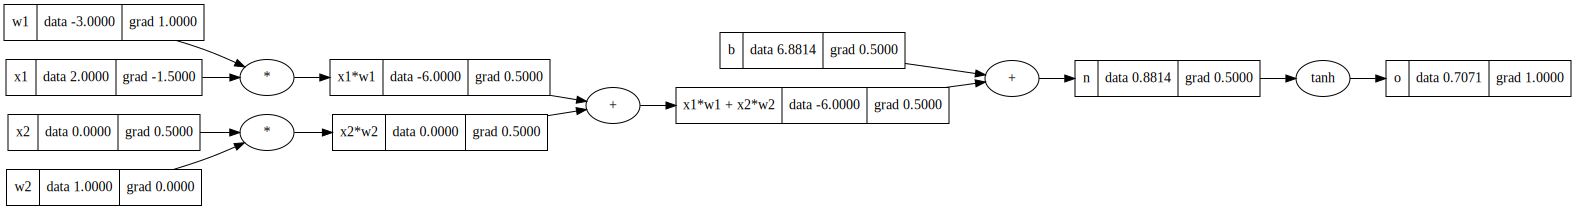

In [5]:
o.backward()
draw_dot(o)

### Here start's the new implementation:
Initially, our `Value` class allows us to do `a + b` if `a` and `b` are objects of `Value` class but it doesn't let's us do `a + 1` and issues warning `'int' object has no attribute 'data'`.

__let's fix `a + 1`:__

We can fix the issue by simply adding a line which will check if other is instance/object of `Value` class if yes, assign as it is but if not then make instance of `Value` class then assign it.
```python
other = other if isinstance(other,Value)else other = Value(other)
```
Although we fix it for `+` but we haven't fixed it for other operators so let's fix them by pasting same line of code into them.

In [6]:
a = Value(1.0)
a + 1

Value(data=2.0)

So far we can do `a + 1` but we can't do `1 + a` or `1 * a` because python doesn't know how to do addition or any other operation between an int or float and a `Value` class object.

__Let's fix it__

We can fix it using `__rmul__`, `__radd__`,etc. As soon as python get's `1 * a` then instead of throwing error, it will check if next variable has `__rmul__` function which will reverse and has `__mul__` operator to handle the operation.
```python
def __rmul__(self,other): # other * self
    return self * other
```
_Note: we did `self * other` instead of `other * self` because our function is itself executing because of `other * self` and we want it in correct form `self * other` so, that the operation execute._

In [7]:
2 * a

Value(data=2.0)

In [8]:
1 + a

Value(data=2.0)

We still have lots of things to implement such as $e^x$,'-','/',etc. Therefore, we will try to implement the those mentioned operators so that we can rewrite our activation function in the form of $tanh = {\frac {e^{2x}-1}{e^{2x}+1}}$instead of `o = n.tanh()`.

1. __Exponential operator($e^x$):__

The `_backward` function is simple because $\frac{d e^x}{dx} = e^x$. Derivative of $e^x$ is itself $e^x$.
```python
def exp(self):
    x=self.data
    out = Value(math.exp(x),(self,),'exp')

    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward
    return out
```

2. __Subtraction operator(-):__

Implementation for this operator is a little bit tricky and it's `_backward` function is calculated by `__add__` operator.
```python
def __neg__(self):# -self
    return self * -1

def __sub__(self,other):# self - other
   return self + (-other)
```
Subtraction can be written as `a - b` or `a + (-b)= a - b`, the implementation uses second logic.

Python is intelligent enough to differenciate between `__neg__` operator and `__sub__` operator.
- `__neg__` refers to unary operation like `-1`, `-a`,etc.
- `__sub__` refers to binary operation like `2 - 1`, `a - b`,etc.

How `_backward` function is calculated?
- When we have a subtraction operator `-` then it uses `__add__` operator's `_backward` function to calculate because we are simply doing `self + (-other)`
- But before doing `__add__` operator, it will pass to `__neg__` operator where, it will calculate `_backward` from `__mul__` operator.
- therefore, this is simple implementation of addition of a positive variable and negative variable.

3. __Power Operator (^):__

Implementation:
```python
def __pow__(self,other):
  assert isinstance (other,(int,float)),'only supporting int/float powers for now'
    out = Value(self.data**other,(self,),f'**{other}')

    def _backward():
      self.grad += other * (self.data**(other - 1)) * out.grad
    out._backward = _backward
    return out'
```
- `__pow__` operator is receiving thhe `self` as `Value` class object and `other` as compulsory `int` or `float` value.
- then we check if other is `int` or `float` if not then we exit function issuing error with our message.
- we simply call the builtin arthimetic power function of python using `**` while forming `out` as `Value` class object.
  - `_backward` function is implemented using arthimetic operation of python to follow the simple derivative rule. our function $f(x) = x ^n$ then it's derivative will be $\frac{dx^n}{dx} = n.x^{n-1}$.

4. __Division operator (/):__

To make it easier for implementation and practical way of implementation, we will implement our `division operator` as `a*b**-1` which can be written in mathematical form this way: $a/b = a * \frac{1}{b}$.
- As we know that $\frac{1}{b}$ can be written as $b^{-1}$.
- Therefore, we can finally write our $a/b = a*b^{-1}$ so, in the form of python code we implement it as:
```python
def __truediv__(self,other):# self/other
    return self * other**-1
```
- As usual, we won't have to implement `_backward` for divison operator because it is a operator which is derived using `__pow__` and `__mul__` opertor so, they will handle and calculate the `_backward` for this operator.

__Common Question to be noted down:__
1. When are the `Value` class operators are getting triggered and when are normal arthimetic builtin operators are triggering?

Answer: The `Value` class `operators` will trigger only when we are performing the operation between two `Value` class `objects` like if `a` and `b` are `value` class object then `a + b` will trigger `__add__` operator as operation is happening between two `Value` class `object` to form final outcome as another `Value` class object.

The `Value` class objects won't trigger if our operation is like this `a.data + b.data` because we are performing operation between two float value stored in the attribute of `Value` class object's therefore, it will trigger simple arthimetic operator of builtin python which is `+`.

2. What is (self,other) in each operator function of `Value` class?

Answer: `self` is `Value` class object but `other` could be either `float or int` value or object of `Value` class. That's why we have this line of code in each opertor:
```python
other = other isinstance (other,Value) else Value(other)
```
which checks if other is object of `Value` class if yes then let it be or else change it to `Value` class object before moving forward.

But `exception` applies to our `__pow__` operator which explicitly expects `other` parameter as either `int` or `float` value. That's why we have this line of code:
```python
assert isinstance (other,(int,float)),'only supporting int/float powers for now'
```
which will check if other is `int or float` if not the fuction will raise an error with our written message.

3. Is our `Value` class operators getting triggered inside `_backward` function stored inside the operator function we implemented?

Answer: The answer to this question is straight __NO__. All the `_backward` functions are designed to perform raw arthemtic calculation. So, if we see `**b` or `*` or any other operator used inside the `_backward` function then we need to understand we are doing arthimetic operations. Specially, to avoid triggering of `Value` class operator functions from triggering all the calculation inside `_backward` functions are done calling `.data` attribute of each `Value` class object.

__Impelementation of above neuron without using `tanh` instead using simple form $\frac{e^{2x}-1}{e^{2x}+1}$ inorder to check if our `__pow__`, `__trudiv__`, `__sub__`, `__neg__`and `__exp__` operators are working__

We can see our implementation is calculating correct gradient for all the nodes so, our implementation is correct.

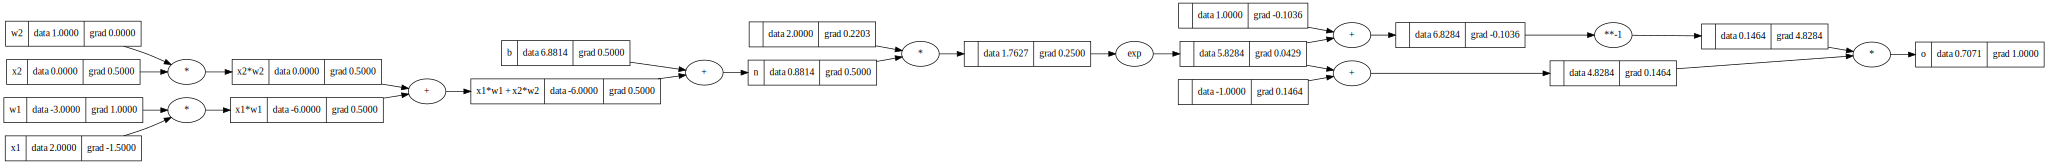

In [9]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# ----
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ----
o.label = 'o'
o.backward()
draw_dot(o)

#### Implementation using pytorch:

By default the pytorch produces data-type of `float32` but we want it them in `double` so, we will explicitly make them `double` using `.double()`. And `double` is data-type `float 64`.

In order to particularly look into the tensor storing number, we need to do `tensor.data.item`

In [10]:
import torch

x1 = torch.tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.tensor([1.0]).double(); w2.requires_grad = True
b = torch.tensor([6.8813735870195432]).double(); b.requires_grad = True

n = x1*w1 + x2*w2 + b

o = torch.tanh(n)

print (o.data.item())

# we will do backward
o.backward()
# now, we can look into newly stored gradient at each tensors
print('------')
print('x1', x1.grad.item())
print('w1', w1.grad.item())
print('x2', x2.grad.item())
print('w2', w2.grad.item())

0.7071066904050358
------
x1 -1.5000003851533106
w1 1.0000002567688737
x2 0.5000001283844369
w2 0.0


### Implementation of Multi-layer perceptron (MLP) to see our `Value` calss work
We can visually, understand the MLP looking at this picture. The picture clearly, describes the very first input goes to the first layer than after that output of each neuron from that layer goes to each neuron of the another layer and samething continues that's how the output of previous layer is passed to forward layer finally resulting in the output.

![MLP-visual-input-passing diagram](./mlp_visual.png)

__Major question in our mind: Do we need to memorize the Neuron or any other class?__
Answer: No, we don't. We only need to understand what is the purpose or __Neuron__, __Layer__ or __Perceptron__ class then we can implement our own custom class. In real world, we never implement them from scratch like this.

__Things, we actually need to know or memorize__

__class Neuron__
- A neuron has weights and a bias. (These are the parameters the AI will "learn").
- A neuron performs a dot product. (Multiply inputs by weights and add the bias).
- A neuron applies an activation function. (To make it non-linear).
- A neuron may have a helper function to return all the parameters and bias of it because when we eventually write an optimizer, the only things that can change to improve model's learning are the weights (w) and the bias (b).

In [11]:
import random

class Neuron:
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    # w*x+b
    # Start with the bias
    out = self.b
    # Loop to add all the w*x multiplications
    for wi, xi in zip(self.w, x):
      out += wi * xi

    # Save the result of tanh()!
    out = out.tanh()
    return out

  def parameters(self):
    return self.w + [self.b] # this will return list containing a list of all the weights and bias of the particular neuron

__Layer__

Layer is just a collection of Neurons working side-by-side. Think of it like a row of workers, where every worker receives the same input and produces their own output.

__Things we actually need to know or memorize:__

__class Layer:__
- A layer contains a list of neurons and a `Layer` class requires number of input `(nin)` to pass into each neuron and number of output `(nout)` to determine how many `neuron` are required in that layer.
- A layer passes same input to each neuron of a that particular layer and output of that particular layer is returned to pass as input for another layer.
- A helper function `parameter` might be required to get return the list of parameter of each neuron of that layer.

In [12]:
class Layer:
  def __init__(self, nin, nout):
    self.neurons = []
    for i in range(nout):
      self.neurons.append(Neuron(nin))

  def __call__(self, x):
    outs = []
    for n in self.neurons:
      outs.append(n(x))

    if len(outs) == 1:
      return outs[0]
    else:
      return outs

  def parameters(self):
    param = []
    for neuron in self.neurons:
      for p in neuron.parameters():
        param.append(p)
    return param


__Multi-Layer perceptron (MLP)__

MLP is the entire brain of neural network or it can be defined as group of layers.

__Things we actually need to know or memorize__

__class MLP:__
- MLP contains a list of layers and a `MLP` class requires number of input `(nin)` required to pass in each layer and number of output `(nout)` expected from each layer.
  - MLP passes the output of previous layer as input for current layer and output of current layer as input for next layer. E.g. prev_layer --output--> cur_layer --output--> next_layer. MLP is responsible for forming this handshake between layers.
- MLP returns the output of final layer as final outcome of the MLP.
- MLP might require a helper function `parameter` to return the parameter of each neuron of each layers inside the MLP.

__The "Big Picture"__

- Value: The smallest atom (handles the math + backprop).
- Neuron: The next level up (handles dot products + activation).
- Layer: The next level up (a group of neurons).
- MLP (Multi-Layer Perceptron): The next level (a group of layers).

In [13]:
class MLP:
  def __init__(self,nin,nouts):
    sz = [nin]+nouts # nouts is already a list and we are making nin list then using '+' operator combines these two list into one combined list
    self.layers =[]
    for i in range(len(nouts)):
      self.layers.append(Layer(sz[i],sz[i+1])) # we are passing number of output of one layer as number of input for next layer

  def __call__(self,x):
    for layer in self.layers:
      x = layer(x) # we are passing inputs to a layer then it's output as input to another layer
    return x # we will return the output of final layer as output of MLP

  def parameters(self):
    param = []
    for layer in self.layers:
      for p in layer.parameters():
        param.append(p)
    return param

Let's see our MLP works and prediction:

So, we made a new MLP then passed some random input into it to see if the MLP works. And it does works because we got something as an output. The output is random because our model isn't trained into any dataset.
```python
n = MLP(3,[4,4,1])
```
This means:
- We have created MLP by passing three inputs in the first layer.
- We have created 3 layer MLP which has:
  - 4 neurons in first layer
  - 4 neurons in second layer
  - third is final layer with only 1 neuron

Visual diagram of our implemented MLP:

![Implemented MLP diagram](./mlp_implemented.png)

In [14]:
x = [2.0, 3.0, -1.0]
n = MLP(3,[4,4,1])
n(x)

Value(data=-0.45171326441099124)

Let's create a random dummpy traning dataset to train our MLP and desired output to evaluate and improve the MLP.

In [15]:
# training dataset
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

Let's see what our prediction are for the training dataset and how they differ from the targeted prediction.

In [16]:
y_pred = [n(x) for x in xs]
y_pred

[Value(data=-0.45171326441099124),
 Value(data=0.20636988655990174),
 Value(data=-0.47668963263202885),
 Value(data=0.1281792884240297)]

Less calculate the loss (Mean square error) so, that we run `.backward()` and calculate `grad` for each weights to improve the model.

In [17]:
losses = [(yout - ygt)**2 for ygt, yout in zip(ys,y_pred)]
losses

[Value(data=2.107471402066816),
 Value(data=1.4553283031985502),
 Value(data=0.2738537405948009),
 Value(data=0.7600713531328311)]

but `loss` is the sum of all the values calculated by subtraction of targeted prediction from actual prediction's square.

In [18]:
loss = sum(losses,Value(0))# loss = sum((yout-ygt)**2 for ygt, yout in zip(ys,y_pred))
loss

Value(data=4.596724798992998)

Now, we can run `loss.backward()` to calculate `grad` for each weights and then improve the training by twerking it. We can see the diagram of our loss calculation and then grad for each nodes being calculated.

If we want, we can manually look into the `.grad` attribute to see calculated gradient during `.backward()` and `.data` attribute which will be our target to change to improve according to `.grad`. Or we can directly look at all the parameters of this MLP.

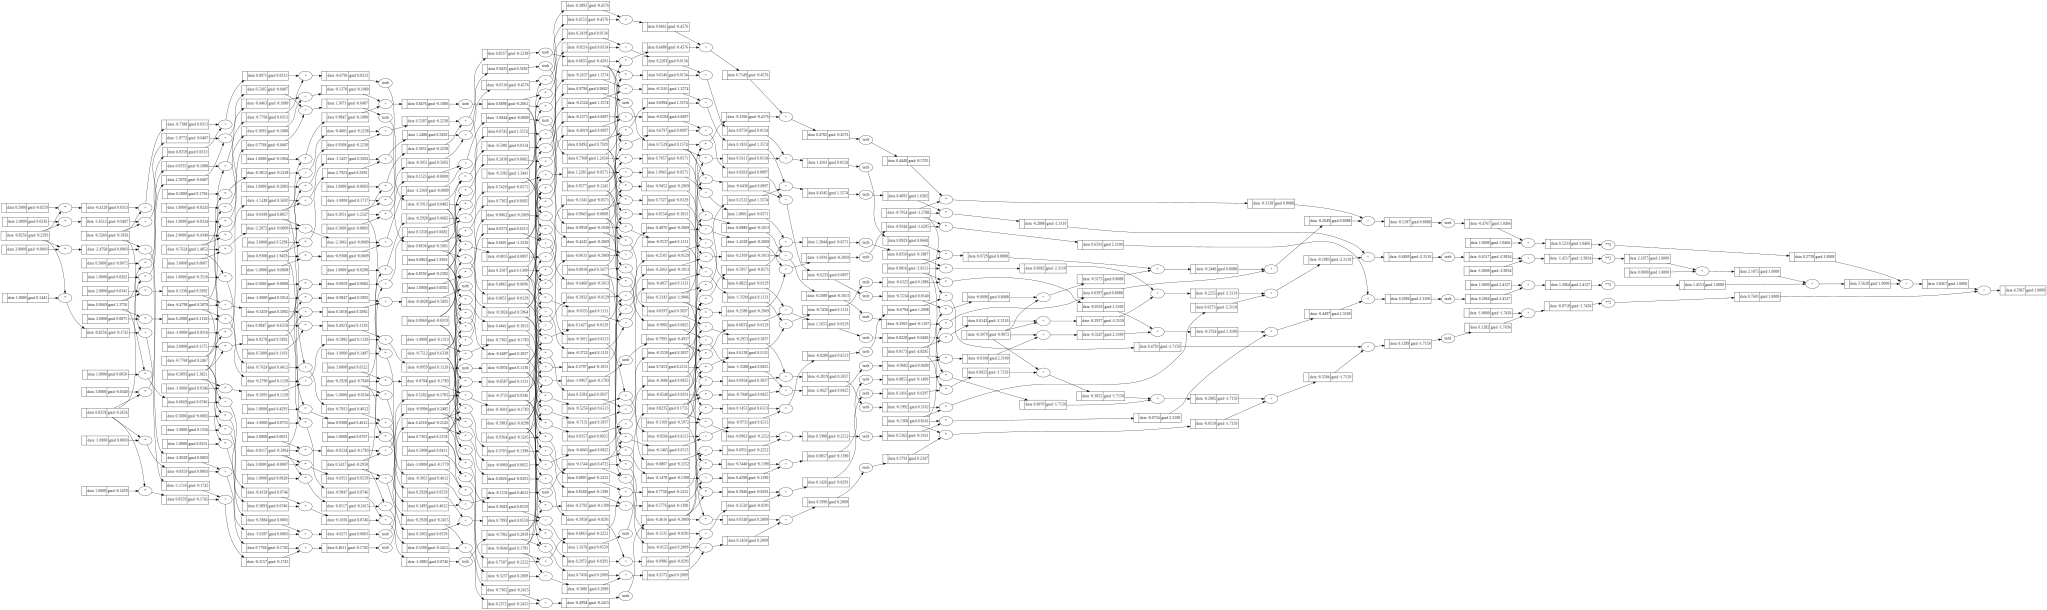

In [19]:
loss.backward()
draw_dot(loss)

In [20]:
n.layers[0].neurons[0].w[0].grad

-0.23931266523548783

In [21]:
n.layers[0].neurons[0].w[0].data

-0.8256029746774824

In [22]:
n.parameters

<bound method MLP.parameters of <__main__.MLP object at 0x7fbd799b4a10>>

Let's improve the MLP by twerking `.data` attribute according to the calculated `.grad` attribute.

In [23]:
learning_rate = 0.1
for p in n.parameters():
  p.data -=learning_rate * p.grad

y_pred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt,yout in zip(ys,y_pred))
loss

Value(data=1.8735030303996063)

As we can see our one-round of training has improved the MLP by twerking the `parameters aka weights` of the MLP based on `.grad`. As a proof, we have decrease in the value of loss which shows our MLP has improved.

Now, instead of writing the training codes again and again, we can simply write a simple training loop which will do the same thing to imporve the model without repeatation of the code.

__Things to remember while writing a training loop:__

- reset the previous `gradient` of each parameter.
- do forward pass by passing input to the MLP then get the output
- calculate the loss from the received prediction by comparing to targetted predicition.
- do backward pass by running `.backward()` to get new gradients according to calculated loss.
- Update the MLP's each parameter according to calculated `gradient` and `learning rate`.

_Note: Never forget to reset the previous gradient before running `.backward()` to do backward pass in order to make sure our MLP learns from recent loss not from wrong accumulated loss._

In [24]:
# training
for k in range(25):
  # reset the previous gradient
  for p in n.parameters():
    p.grad = 0.0

  # 1. Forward pass
  y_pred = [n(x) for x in xs]# get prediction of the data set
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, y_pred)) # calculate loss of each prediction and sum together

  # 2. backward pass
  loss.backward()

  # 3. Update (train and twerk the MLP)
  for p in n.parameters():
    p.data -= 0.1 * p.grad

  print(f'training loop run: {k}, {loss}')


training loop run: 0, Value(data=1.8735030303996063)
training loop run: 1, Value(data=0.7721282773075998)
training loop run: 2, Value(data=0.26164883171167264)
training loop run: 3, Value(data=0.1751495521088149)
training loop run: 4, Value(data=0.1300639477161762)
training loop run: 5, Value(data=0.10260604872083283)
training loop run: 6, Value(data=0.08425213376605264)
training loop run: 7, Value(data=0.07118130540811268)
training loop run: 8, Value(data=0.06143408073530381)
training loop run: 9, Value(data=0.05390617697956458)
training loop run: 10, Value(data=0.047929843403049635)
training loop run: 11, Value(data=0.043078552317790286)
training loop run: 12, Value(data=0.03906762821151549)
training loop run: 13, Value(data=0.03570010562291011)
training loop run: 14, Value(data=0.032835544204809386)
training loop run: 15, Value(data=0.030371219881596558)
training loop run: 16, Value(data=0.028230331073634953)
training loop run: 17, Value(data=0.026354353722712512)
training loop run:

Looking at our trained MLP's prediction, we can say, we are near the perfection as the predicited value are super close to targeted prediction.

In [25]:
y_pred

[Value(data=0.9546200311124096),
 Value(data=-0.9246187141530021),
 Value(data=-0.9255967852574548),
 Value(data=0.9327840827038969)]

This is our final trained MLP with the final updated parameters.

In [26]:
n.parameters()

[Value(data=-0.7134295322304847),
 Value(data=0.9123080916675677),
 Value(data=-1.0256818452314633),
 Value(data=-0.2758350245449225),
 Value(data=-0.033173214325864134),
 Value(data=0.19329024648038862),
 Value(data=1.113355024670988),
 Value(data=-0.48431470548090494),
 Value(data=-0.6875765307820816),
 Value(data=0.9914728719544111),
 Value(data=0.22622326157587175),
 Value(data=0.08202619596984709),
 Value(data=-0.052497215456909635),
 Value(data=-0.25577419852006716),
 Value(data=0.7822004958927506),
 Value(data=0.5325775926710873),
 Value(data=0.22767839856789202),
 Value(data=-0.6191649896862431),
 Value(data=0.882919832716493),
 Value(data=-1.0488777352054148),
 Value(data=-0.3383950452643446),
 Value(data=1.047448815678279),
 Value(data=0.22344170407318326),
 Value(data=0.9702037980860924),
 Value(data=0.5960727925740149),
 Value(data=0.5290999685731516),
 Value(data=-0.9931284148588457),
 Value(data=-0.7544846881932818),
 Value(data=0.07179991811203862),
 Value(data=0.1008542

__Common questions:__
1. Why is it a flat list, not a nested mess like [[[param1, parma2, param3, param4],[param1, parma2, param3, param4],....]] although the implementation looks like that?

Answer: When you define `n.parameters()`, you are writing a utility function. Its only job is to go into every neuron, grab the weights and biases, and put them into one simple list. While reading the code it looks like we should expect the nested list of parameters but when we look into code clearly and try to understand then it is actually implemented to produce a final list containing the list of all parameters only.

2. What counts as a "parameter"?

Answer: Yes, every single weight and every single bias is a parameter.
In our Neuron class, we have:
- A list of w (weights), one for each input connection.
- One b (bias).

If a neuron has 3 inputs, it has 3 weights + 1 bias = 4 parameters.

3. During training: Improve `.grad` or `.data`?

Answer: This is the most important part of the entire journey. Here is how it works:
- `.grad` is the "__Map__": When you run `loss.backward()`, the .grad attribute tells you the direction to move. It answers: "If I increase this specific weight by a tiny bit, how much will the total loss change?"
- `.data` is the "__Position__": The `.data` attribute is the actual current value of the weight.You change the `.data` to improve the network.

You don't "improve" the gradient; you use the gradient to update the data. The update rule is:
$$new\_data = old\_data - (learning\_rate \times grad)$$